# 8. Visualization

In this tutorial, you will learn how to use the `astrometrics.visualization` registry to render two kinds of dashboard: one showing an entire target's field of stars, and one focused on a single star's light curve and spectrum.

## 8.1 The Target Dashboard

The target dashboard shows an entire field at once: the stacked FITS image with every identified star marked, alongside a panel that shows the selected star's light curve (if photometry has been run) or spectrum (if spectroscopy has been run).

Rendering target dashboard for M 13...


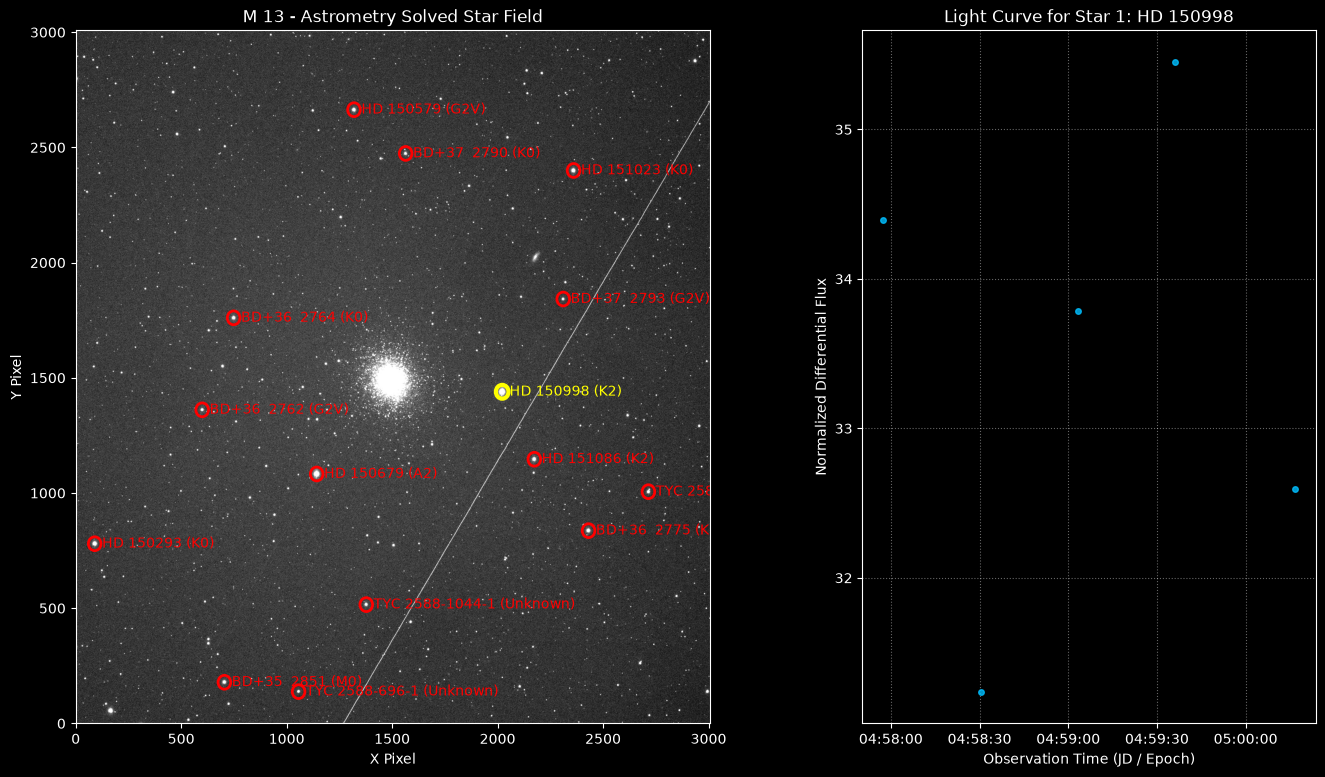

In [1]:
from astrometricslib import Astrometrics

astrometrics = Astrometrics()
target = astrometrics.targets.get("M 13")

print(f"Rendering target dashboard for {target.id}...")
target_figure = astrometrics.visualization.plot_target_dashboard(target)
target_figure.show()

## 8.2 The Star Dashboard

Where the target dashboard shows the whole field, the star dashboard zooms in on one star: its light curve and its calibrated spectrum, stacked in a single two-panel figure. A star's spectrum lives on a separate stellar object from its light curve when spectroscopy was run against a different target than photometry was -- as with the bundled sample data, where "M 13" holds the photometry and "M 13 Spectroscopy" holds the spectra -- so `plot_star_dashboard()` takes the spectrum's stellar object as a second, optional argument.

Rendering star dashboard for NGC  6205   620...


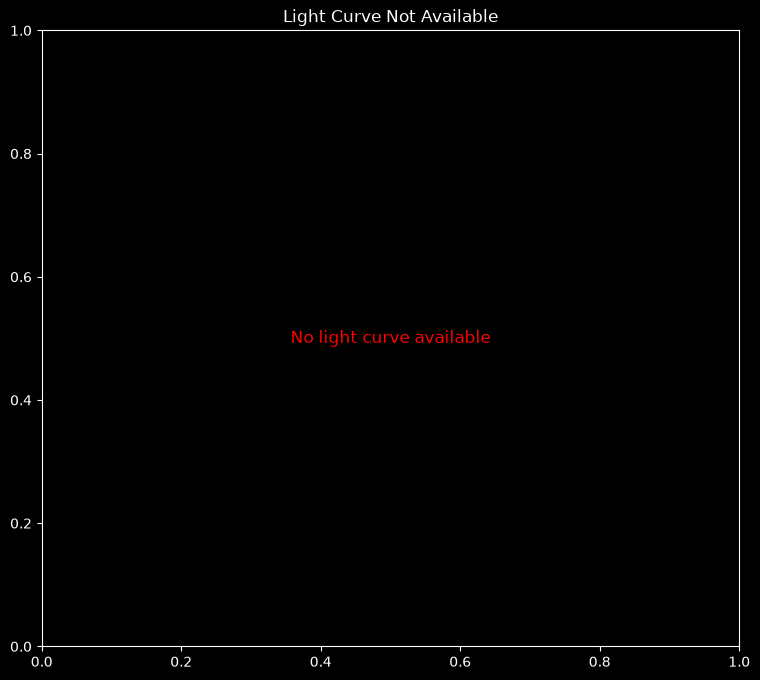

In [2]:
stellar_objects = [obj for obj in astrometrics.stars.list_objects() if target.id in obj.target_ids]

if stellar_objects:
    selected_star = stellar_objects[0]
    spectral_star = astrometrics.stars.get_object(f"{selected_star.id}::spectroscopy")
    print(f"Rendering star dashboard for {selected_star.id}...")
    star_figure = astrometrics.visualization.plot_star_dashboard(selected_star, spectral_star=spectral_star)
    star_figure.show()
else:
    print("No stellar objects were identified for this target; skipping the star dashboard.")